<a href="https://colab.research.google.com/github/MarkusFuchs68/Covid-19_detection/blob/main/notebooks/4%20-%20finetuning_model_vgg16_4_classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from '/content/helper.py'>

### Transfer Learning

##### Dataset loading and preprocessing

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import os
import shutil
import kagglehub

# Download dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# Move dataset to parent directory
shutil.move(os.path.join(path, 'COVID-19_Radiography_Dataset'), "..")
print("Covid-19 Radiography Dataset downloaded and moved to parent directory.")

In [5]:
# Read in the images
train_ds, val_ds, class_names = helper.read_only_xray_images()

Created empty directory: /tmp_724690719
Made directory: /tmp_724690719/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_724690719/Lung_Opacity/masks
Made directory: /tmp_724690719/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_724690719/Viral Pneumonia/masks
Made directory: /tmp_724690719/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_724690719/COVID/masks
Made directory: /tmp_724690719/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_724690719/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 224, 224, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 224, 224, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_724690719/Lun

In [6]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [7]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [8]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

# We apply preprocessing now in the model itself, so there will be no further need, when later the model is used on raw images
#train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
#val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [9]:
# This model name for saving and loading
model_name = 'finetuning_vgg16_' + str(len(class_names)) + '-classes.keras'

In [31]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Let the layers of the base model retrain, starting from the pretrained weights
base_model.trainable = True

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Preprocess the image
x = preprocess_input(inputs)

# Build the model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(128, activation='relu')(x) # was before 512, let's see, if 128 performs better
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

In [11]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [32]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = helper.model_summary_to_df(vgg16)
display(df_summary)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13            │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_18 (GetItem)     │ (None, 224, 224)       │              0 │ input_layer_13[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_19 (GetItem)     │ (None, 224, 224)       │              0 │ input_layer_13[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_20 (GetItem)     │ (None, 224, 224)       │              0 │ input_layer_13[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack_6 (Stack)           │ (None, 224, 224, 3)    │              0 │ get_item_18[0][0],     │
│                           │                        │                │ get_item_19[0][0],     │
│                           │                        │                │ get_item_20[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 224, 224, 3)    │              0 │ stack_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 7, 7, 512)      │     14,714,688 │ add_6[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 1024)           │        525,312 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 1024)           │              0 │ dense_18[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_19 (Dense)          │ (None, 128)            │        131,200 │ dropout_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_13 (Dropout)      │ (None, 128)            │              0 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 4)              │            516 │ dropout_13[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 15,371,716 (58.64 MB)

 Trainable params: 15,371,716 (58.64 MB)

 Non-trainable params: 0 (0.00 B)

,Layer Name (type),Output Shape,Param Count
0,input_layer_13,"(None, 224, 224, 3)",-
1,(InputLayer),,
2,get_item_18 (GetItem),"(None, 224, 224)",input_layer_13[0][0]
3,get_item_19 (GetItem),"(None, 224, 224)",input_layer_13[0][0]
4,get_item_20 (GetItem),"(None, 224, 224)",input_layer_13[0][0]
5,stack_6 (Stack),"(None, 224, 224, 3)","get_item_18[0][0],"
6,,,"get_item_19[0][0],"
7,,,get_item_20[0][0]
8,add_6 (Add),"(None, 224, 224, 3)",stack_6[0][0]
9,vgg16 (Functional),"(None, 7, 7, 512)",add_6[0][0]


In [33]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - accuracy: 0.2798 - loss: 2.2973 - val_accuracy: 0.6586 - val_loss: 0.8852 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.6415 - loss: 0.7129 - val_accuracy: 0.7680 - val_loss: 0.5671 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.7436 - loss: 0.5156 - val_accuracy: 0.8335 - val_loss: 0.4445 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.7840 - loss: 0.4313 - val_accuracy: 0.7983 - val_loss: 0.5440 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.8072 - loss: 0.3896 - val_accuracy: 0.8245 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.8405 - loss: 0.3321 - val_accuracy: 0.8540 - val_loss: 0.4013 - learning_rate: 0.0010
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.8521 - l

In [34]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

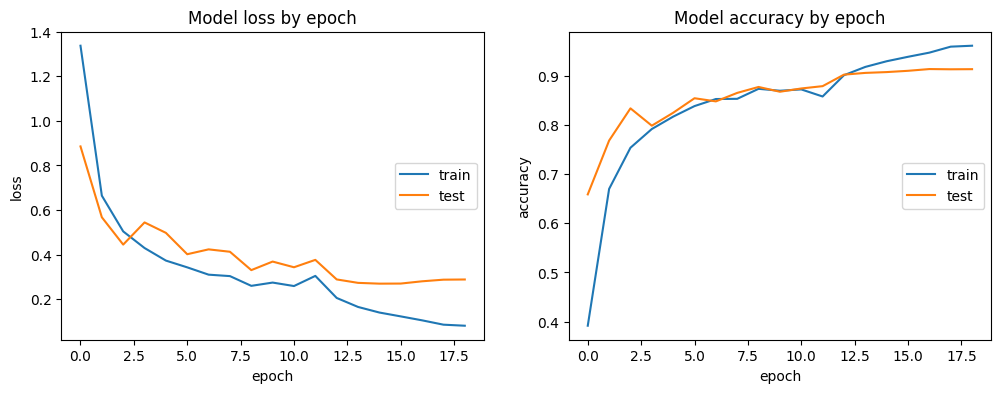

In [35]:
helper.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [36]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [37]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = helper.get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.934247,0.956522,0.986364,0.945253,0.971328,0.940663,713.000000
Lung_Opacity,0.877148,0.876395,0.953390,0.876771,0.914082,0.829113,1165.000000
Normal,0.923492,0.914966,0.928276,0.919209,0.921597,0.848210,2058.000000
Viral Pneumonia,0.930000,0.939394,0.994665,0.934673,0.966634,0.929218,297.000000
avg_pre,0.913005,0.913005,0.913005,0.913005,0.913005,0.913005,0.913005
avg_rec,0.913064,0.913064,0.913064,0.913064,0.913064,0.913064,0.913064
avg_spe,0.949630,0.949630,0.949630,0.949630,0.949630,0.949630,0.949630
avg_f1,0.913001,0.913001,0.913001,0.913001,0.913001,0.913001,0.913001
avg_geo,0.931065,0.931065,0.931065,0.931065,0.931065,0.931065,0.931065
avg_iba,0.864211,0.864211,0.864211,0.864211,0.864211,0.864211,0.864211


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,682,15,13,3
Lung_Opacity,17,1021,126,1
Normal,30,128,1883,17
Viral Pneumonia,1,0,17,279


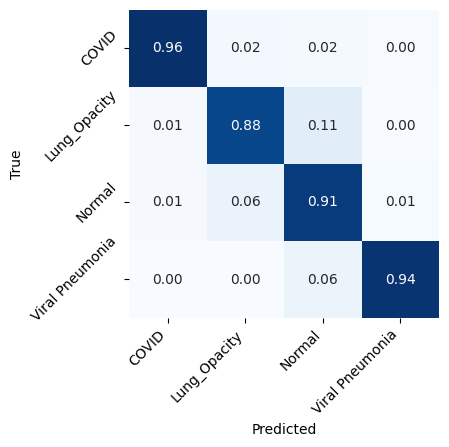

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              682            15      13                3
 Lung_Opacity        17          1021     126                1
 Normal              30           128    1883               17
 Viral Pneumonia      1             0      17              279,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.934247     0.956522     0.986364     0.945253   
 Lung_Opacity        0.877148     0.876395     0.953390     0.876771   
 Normal              0.923492     0.914966     0.928276     0.919209   
 Viral Pneumonia     0.930000     0.939394     0.994665     0.934673   
 avg_pre             0.913005     0.913005     0.913005     0.913005   
 avg_rec             0.913064     0.913064     0.913064     0.913064   
 avg_spe             0.949630     0.949630     0.949630     0.949630   
 avg_f1              0.913001     0.913001     0.913001     0.913001   

In [38]:
helper.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes really well